# Test wind function

In [1]:
import sys
sys.path.append('../code')
import importlib

import numpy as np
import pandas as pd

import SeaLevelContrib as slc


In [2]:
importlib.reload(slc)

<module 'SeaLevelContrib' from 'C:\\Users\\kyrab\\Github\\SLBudget\\notebooks\\../code\\SeaLevelContrib.py'>

## This is the old function that allows to take a list of tide gauges in input

In [3]:
def make_wpn_ef_old(tg_id, tgm_df, with_nodal, with_trend, product):
    
    for i in range( len(tg_id)):
        tg_lat, tg_lon = slc.tg_lat_lon(tg_id[i])                                                      # finds the latitude and longitude of a given tide gauge id
        annual_wind_df = slc.make_wind_df(tg_lat, tg_lon, product)                                     # makes a dataframe with vor every year on the specific location: the u, v, speed, and presure and some other values
        df_c = tgm_df.join(annual_wind_df, how='inner')                                                # adds the values of annual wind df to the tgm_df dataset (in this case columns are added at the right)
        df_c.index.names = ['year']         # adds a index name

        print(df_c) 
        linear_fit, names = slc.linear_model_zsm(df_c, with_trend, with_nodal, 
                                             with_wind=True, with_pres=True, with_ar=False)            #Creates linear fits: Makes array with u**2, v**2, pressure, nodal cycle influence, years from 1970 array and creates a fit.
                                                                                                       #linear fit: for evvery year: sea level hight = a).1+a1.wind+....+ai*nodal +error solve this linear equation
        time_y = df_c.index
        mod = np.array(linear_fit.params[:]) * np.array(linear_fit.model.exog[:,:])
        
        w_ef = mod[:,[1,2]].sum(axis=1)
        p_ef = mod[:,3]
        
        if with_nodal:
            n_ef = mod[:,[4,5]].sum(axis=1)
            
        if i==0:
            if with_nodal:
                n_ef_df = pd.DataFrame(data=dict(time=time_y, col_name=n_ef))
                n_ef_df = n_ef_df.set_index('time')
                n_ef_df.columns  = [str(tg_id[i])] 
            w_ef_df = pd.DataFrame(data=dict(time=time_y, col_name=w_ef))
            w_ef_df = w_ef_df.set_index('time')
            w_ef_df.columns  = [str(tg_id[i])]
            p_ef_df = pd.DataFrame(data=dict(time=time_y, col_name=p_ef))
            p_ef_df = p_ef_df.set_index('time')
            p_ef_df.columns  = [str(tg_id[i])]
        else:
            if with_nodal:
                n_ef_df[str(tg_id[i])] = n_ef
            w_ef_df[str(tg_id[i])] = w_ef
            p_ef_df[str(tg_id[i])] = p_ef
            
    if with_nodal:
        wpn_ef_df = pd.DataFrame(data=dict(time=time_y, Nodal=n_ef_df.mean(axis=1), 
                        Wind=w_ef_df.mean(axis=1), Pressure=p_ef_df.mean(axis=1)))
    else:
        wpn_ef_df = pd.DataFrame(data=dict(time=time_y, 
                Wind=w_ef_df.mean(axis=1), Pressure=p_ef_df.mean(axis=1)))
        
    wpn_ef_df = wpn_ef_df.set_index('time')
    
    return wpn_ef_df


In [4]:

import xarray as xr

PATH_SLBudgets_data = '/Users/kyrab/Github/SLBudget/data/'
ERA5_dir = PATH_SLBudgets_data + 'WindPressure/ERA5/' 

# Define a few constants
er = 6.371e6 # Earth's radius in meters
oa = 3.6704e14 # Total ocean area m**2
rho_o = 1030 # Density of ocean water
g = 9.81 # Acceleration of gravity

def find_closest(lat, lon, lat_i, lon_i):
    """lookup the index of the closest lat/lon"""
    Lon, Lat = np.meshgrid(lon, lat)
    idx = np.argmin(((Lat - lat_i)**2 + (Lon - lon_i)**2))
    Lat.ravel()[idx], Lon.ravel()[idx]
    [i, j] = np.unravel_index(idx, Lat.shape)
    return i, j


def tg_lat_lon(tg_id):
    '''Return tide gauge latitude, longitude location given the id as input'''
    
    tg_data_dir = PATH_SLBudgets_data + 'rlr_annual'
    names_col = ('id', 'lat', 'lon', 'name', 'coastline_code', 'station_code', 'quality')
    filelist_df = pd.read_csv(tg_data_dir + '/filelist.txt', sep=';', header=None, names=names_col)
    filelist_df = filelist_df.set_index('id')
    
    return filelist_df.loc[tg_id].lat, filelist_df.loc[tg_id].lon

lat_i, lon_i = tg_lat_lon(20)


u_file = ERA5_dir + 'ERA5_u10.nc'
v_file = ERA5_dir + 'ERA5_v10.nc'
p_file = ERA5_dir + 'ERA5_p_msl.nc'
latn = 'latitude'
lonn = 'longitude'
timen = 'valid_time'
un = 'u10'
vn = 'v10'
pn = 'msl'

ds_u = xr.open_dataset(u_file)
ds_v = xr.open_dataset(v_file)
ds_p = xr.open_dataset(p_file)

display(ds_p)


# read lat, lon, time from 1 dataset
lat, lon = ds_u[latn][:], ds_u[lonn][:]
print(lat)
print(lon)
print(ds_u[latn])
# this is the index where we want our data
i, j = find_closest(lat, lon, lat_i, lon_i)  #finds the closests grid ponit for that one tide gauge station. 
print(i)
print(j)
# get the u, v, p variables
print('found point', float(lat[i]), float(lon[j]))    
u = ds_u[un][:, i, j]
display(u)

v = ds_v[vn][:, i, j]
pres = ds_p[pn][:, i, j]
pres = pres - pres.mean()

# compute derived quantities
speed = np.sqrt(u**2 + v**2)

# Inverse barometer effect in cm
ibe = - pres/(rho_o*g)*100
ibe = ibe - ibe.mean()

# compute direction in 0-2pi domain
direction = np.mod(np.angle(u + v * 1j), 2*np.pi)

# Compute the wind squared while retaining sign, as an approximation of stress
#u2 = u**2 * np.sign(u)
#v2 = v**2 * np.sign(v)
wind_magnitude = np.sqrt(u**2 + v**2)
u2 = wind_magnitude*u
v2 = wind_magnitude*v

# put everything in a dataframe
wind_df = pd.DataFrame(data=dict(u=u, v=v, t=u[timen], speed=speed, 
                                 direction=direction, u2=u2, v2=v2, 
                                 pres=pres, ibe=ibe))
wind_df = wind_df.set_index('t')

annual_wind_df = wind_df.groupby(wind_df.index.year).mean()
    

annual_wind_df


<xarray.Dataset> Size: 3MB
Dimensions:     (valid_time: 1028, latitude: 24, longitude: 30)
Coordinates:
    number      int64 8B ...
  * valid_time  (valid_time) datetime64[ns] 8kB 1940-01-01 ... 2025-08-01
  * latitude    (latitude) float64 192B 55.19 54.94 54.69 ... 49.94 49.69 49.44
  * longitude   (longitude) float64 240B 1.59 1.84 2.09 2.34 ... 8.34 8.59 8.84
    expver      (valid_time) <U4 16kB ...
Data variables:
    msl         (valid_time, latitude, longitude) float32 3MB ...
Attributes:
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2025-09-23T09:16 GRIB to CDM+CF via cfgrib-0.9.1...

<xarray.DataArray 'latitude' (latitude: 24)> Size: 192B
array([55.19, 54.94, 54.69, 54.44, 54.19, 53.94, 53.69, 53.44, 53.19, 52.94,
       52.69, 52.44, 52.19, 51.94, 51.69, 51.44, 51.19, 50.94, 50.69, 50.44,
       50.19, 49.94, 49.69, 49.44])
Coordinates:
    number    int64 8B ...
  * latitude  (latitude) float64 192B 55.19 54.94 54.69 ... 49.94 49.69 49.44
Attributes:
    units:             degrees_north
    standard_name:     latitude
    long_name:         latitude
    stored_direction:  decreasing
<xarray.DataArray 'longitude' (longitude: 30)> Size: 240B
array([1.59, 1.84, 2.09, 2.34, 2.59, 2.84, 3.09, 3.34, 3.59, 3.84, 4.09, 4.34,
       4.59, 4.84, 5.09, 5.34, 5.59, 5.84, 6.09, 6.34, 6.59, 6.84, 7.09, 7.34,
       7.59, 7.84, 8.09, 8.34, 8.59, 8.84])
Coordinates:
    number     int64 8B ...
  * longitude  (longitude) float64 240B 1.59 1.84 2.09 2.34 ... 8.34 8.59 8.84
Attributes:
    units:          degrees_east
    standard_name:  longitude
    long_name:      longitude
<xar

<xarray.DataArray 'u10' (valid_time: 1028)> Size: 4kB
[1028 values with dtype=float32]
Coordinates:
    number      int64 8B ...
  * valid_time  (valid_time) datetime64[ns] 8kB 1940-01-01 ... 2025-08-01
    latitude    float64 8B 51.44
    longitude   float64 8B 3.59
    expver      (valid_time) <U4 16kB ...
Attributes: (12/32)
    GRIB_paramId:                             165
    GRIB_dataType:                            an
    GRIB_numberOfPoints:                      720
    GRIB_typeOfLevel:                         surface
    GRIB_stepUnits:                           1
    GRIB_stepType:                            avgua
    ...                                       ...
    GRIB_totalNumber:                         0
    GRIB_units:                               m s**-1
    long_name:                                10 metre U wind component
    units:                                    m s**-1
    standard_name:                            unknown
    GRIB_surface:                             0.0

,u,v,speed,direction,u2,v2,pres,ibe
t,,,,,,,,
1940,1.111099,0.557550,2.259735,2.120966,3.455343,1.891229,62.861979,-0.622053
1941,0.824189,0.393130,2.055180,2.867685,2.989039,1.612109,-1.390625,0.013840
1942,0.681650,0.575858,2.025898,2.146821,2.175812,1.824030,86.810547,-0.859067
1943,1.468590,0.577574,1.908563,2.296973,4.172463,1.715233,197.639323,-1.955915
1944,1.478949,-0.052203,2.057723,3.067681,4.533446,0.320229,169.676432,-1.679172
...,...,...,...,...,...,...,...,...
2021,1.087827,0.408839,2.000445,1.822085,2.352000,0.992270,84.210938,-0.833339
2022,1.031111,0.756339,2.349406,3.322895,4.136082,3.851048,154.923177,-1.533163
2023,1.679535,0.975807,2.840223,1.559951,6.329677,3.989127,-105.588542,1.045064


In [5]:
import statsmodels.api as sm
lowess = sm.nonparametric.lowess

tg_id=[20]

tgm_df = slc.tide_gauge_obs(tg_id, interp=False)
tgm_df = tgm_df['Average'].to_frame(name='height').dropna()

tg_lat, tg_lon = tg_lat_lon(tg_id[0])                                  # finds the latitude and longitude of a given tide gauge id
#annual_wind_df = slc.make_wind_df(tg_lat, tg_lon, product) already exists
df_c = tgm_df.join(annual_wind_df, how='inner')

df_c.index.names = ['year']


#display(tgm_df)
##display(annual_wind_df)
#display(df_c)


with_trend='with_trend'
with_nodal='with_nodal'

df=df_c
t = np.array(df.index)
y = df['height']
X = np.ones(len(t))
names = ['Constant']

#print(t)
#print(y)
#print(X)

X = np.c_[ X, df['u2'], df['v2']]
names.extend(['Wind $u^2$', 'Wind $v^2$'])
X = np.c_[X, df['pres']]
names.extend(['Pressure'])
X = np.c_[ X, np.cos(2*np.pi*(t - 1970)/18.613), np.sin(2*np.pi*(t - 1970)/18.613)]
names.extend(['Nodal U', 'Nodal V'])
X = np.c_[X, t - 1970 ]
names.extend(['Trend'])

#print(X)

model = sm.OLS(y, X, missing='drop')
fit = model.fit(cov_type='HC0')
print(fit.params)
print(fit.summary())

#print(names) 


#linear_fit, names = slc.linear_model_zsm(df_c, with_trend, with_nodal, 
 #                                    with_wind=True, with_pres=True, with_ar=False)

linear_fit = fit
display(linear_fit)
time_y = df_c.index

#print(np.array(linear_fit.model.exog[:,:]))
#print(np.array(linear_fit.params[:]) )
mod = np.array(linear_fit.params[:]) * np.array(linear_fit.model.exog[:,:])     #### Calculates all bi*x so every row gives the amount of sea level rise due to different contributors in that year. 
w_ef = mod[:,[1,2]].sum(axis=1)                                                  # Sea level rise due to U an v wind 
p_ef = mod[:,3]                                                                  # Sea level rise due to pressure  

#print(mod[:])


#print(mod[:,[1,2]])
#print(mod[:,3])
#print(mod[:,6])
#print(w_ef)
#print(p_ef)




const    0.963948
x1       1.013781
x2      -0.412932
x3      -0.004574
x4       0.273653
x5      -1.572552
x6       0.208983
dtype: float64
                            OLS Regression Results                            
Dep. Variable:                 height   R-squared:                       0.872
Model:                            OLS   Adj. R-squared:                  0.862
Method:                 Least Squares   F-statistic:                     100.2
Date:                Thu, 02 Oct 2025   Prob (F-statistic):           2.63e-34
Time:                        15:01:01   Log-Likelihood:                -181.52
No. Observations:                  84   AIC:                             377.0
Df Residuals:                      77   BIC:                             394.1
Df Model:                           6                                         
Covariance Type:                  HC0                                         
                 coef    std err          z      P>|z|      [0.025   

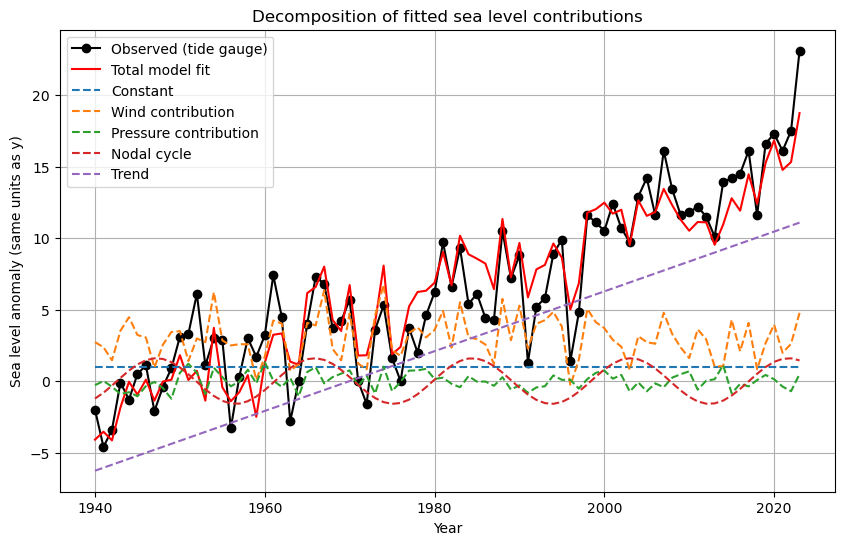

In [6]:
import matplotlib.pyplot as plt

# Extract components by column index
const   = mod[:, 0]
wind    = mod[:, [1, 2]].sum(axis=1)   # u2 + v2
press   = mod[:, 3]                    # pressure 
nodal   = mod[:, [4, 5]].sum(axis=1)   # nodal cos + sin
trend   = mod[:, 6]                    # trend starting with 0 at t = 0
total   = mod.sum(axis=1)              # full reconstructed signal

# Make the plot
plt.figure(figsize=(10,6))

plt.plot(time_y, y, 'ko-', label='Observed (tide gauge)')
plt.plot(time_y, total, 'r-', label='Total model fit')

plt.plot(time_y, const, '--', label='Constant')
plt.plot(time_y, wind, '--', label='Wind contribution')
plt.plot(time_y, press, '--', label='Pressure contribution')
plt.plot(time_y, nodal, '--', label='Nodal cycle')
plt.plot(time_y, trend, '--', label='Trend')

#plt.plot(time_y, wind+press+nodal, label='tot')

plt.xlabel('Year')
plt.ylabel('Sea level anomaly (same units as y)')
plt.title('Decomposition of fitted sea level contributions')
plt.legend()
plt.grid(True)
plt.show()


In [7]:
tg_id = [20]

tgm_df = slc.tide_gauge_obs(tg_id, interp=False)
tgm_df = tgm_df['Average'].to_frame(name='height').dropna()

tgm_df

,height
time,
1862,-2.704321
1863,-4.604321
1864,-8.104321
1865,-5.204321
1866,1.995679
...,...
2019,16.595679
2020,17.295679
2021,16.095679


In [8]:
with_nodal = False
with_trend = True
product = 'ERA5'

wp_old_df = make_wpn_ef_old(tg_id, tgm_df, with_nodal, with_trend, product)

<xarray.Dataset> Size: 3MB
Dimensions:     (valid_time: 1028, latitude: 24, longitude: 30)
Coordinates:
    number      int64 8B ...
  * valid_time  (valid_time) datetime64[ns] 8kB 1940-01-01 ... 2025-08-01
  * latitude    (latitude) float64 192B 55.19 54.94 54.69 ... 49.94 49.69 49.44
  * longitude   (longitude) float64 240B 1.59 1.84 2.09 2.34 ... 8.34 8.59 8.84
    expver      (valid_time) <U4 16kB ...
Data variables:
    u10         (valid_time, latitude, longitude) float32 3MB ...
Attributes:
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2025-09-19T14:15 GRIB to CDM+CF via cfgrib-0.9.1...
found point 51.44 3.59
         height         u         v     speed  direction        u2        v2  \
year                                                

In [9]:
wp_old_df

,Wind,Pressure
time,,
1940,2.897579,-0.209200
1941,2.514375,0.004628
1942,1.617153,-0.288899
1943,3.685201,-0.657729
1944,4.509702,-0.564670
...,...,...
2019,2.938323,0.311404
2020,4.463466,0.091472
2021,2.069011,-0.280248


## New function only takes the coordinates as input

In [10]:
def make_wpn_ef(coord, tgm_df, with_nodal, with_trend, product):
    
    annual_wind_df = slc.make_wind_df(coord[0], coord[1], product)
    df_c = tgm_df.join(annual_wind_df, how='inner')
    df_c.index.names = ['year']
    linear_fit, names = slc.linear_model_zsm(df_c, with_trend, with_nodal, 
                                         with_wind=True, with_pres=True, with_ar=False)
    
    mod = np.array(linear_fit.params[:]) * np.array(linear_fit.model.exog[:,:])
    
    wpn_ef_df = pd.DataFrame(index=df_c.index)
    
    if with_nodal:
        wpn_ef_df['Nodal'] = mod[:,[4,5]].sum(axis=1)
    
    
    wpn_ef_df['Wind'] = mod[:,[1,2]].sum(axis=1)
    wpn_ef_df['Pressure'] = mod[:,3]
    
    return wpn_ef_df

In [ ]:
coord = slc.tg_lat_lon(tg_id[0])

wp_df = make_wpn_ef(coord, tgm_df, False, with_trend, product)

wp_df